# Shor's Algorithm — factoring 15

Shor does not factor numbers directly. It finds a **period**, and the period
gives you the factors.

Pick `a = 7` and look at powers of 7 mod 15:

```
7^1 = 7      7^2 = 4      7^3 = 13     7^4 = 1
7^5 = 7      7^6 = 4      ...
```

It repeats every 4. So `r = 4`. That `r` is the only thing the quantum part finds.
Everything else is ordinary arithmetic.

In [1]:
# !pip install qiskit qiskit-aer matplotlib pylatexenc

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from fractions import Fraction
import numpy as np
import math

sim = AerSimulator()

## The classical part first

No quantum anywhere here. Just to see what we are looking for.

In [2]:
N = 15
a = 7

x = 1
for k in range(1, 9):
    x = (x * a) % N
    print(f"  {a}^{k} mod {N} = {x:2d}")

  7^1 mod 15 =  7
  7^2 mod 15 =  4
  7^3 mod 15 = 13
  7^4 mod 15 =  1
  7^5 mod 15 =  7
  7^6 mod 15 =  4
  7^7 mod 15 = 13
  7^8 mod 15 =  1


It returns to 1 at `k = 4`. **r = 4.**

Then:

```
gcd(7^2 - 1, 15) = gcd(48, 15) = 3
gcd(7^2 + 1, 15) = gcd(50, 15) = 5
```

15 = 3 x 5. Done.

The hard part is finding `r` when `N` is huge. Classically that is slow.
That is the only job the quantum circuit has.

## The multiply-by-7-mod-15 gate

For `N = 15` this happens to be just a few swaps and X gates.
It is hardcoded here because building it properly for general `N` is a whole
project on its own.

In [3]:
def c_amod15(a, power):
    U = QuantumCircuit(4)
    for _ in range(power):
        if a in [2, 13]:
            U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
        if a in [7, 8]:
            U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        if a in [4, 11]:
            U.swap(1, 3); U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)
    g = U.to_gate()
    g.name = f"{a}^{power} mod 15"
    return g.control()


def iqft(n):
    qc = QuantumCircuit(n)
    for i in range(n//2):
        qc.swap(i, n-1-i)
    for j in range(n):
        for k in range(j):
            qc.cp(-np.pi / 2**(j-k), k, j)
        qc.h(j)
    return qc


print("ready")

ready


## The circuit

- 4 **counting** qubits — these hold the answer
- 4 **work** qubits — these hold the running value of `7^k mod 15`

Steps: `H` on the counting register, controlled multiplications, inverse QFT,
measure the counting register.

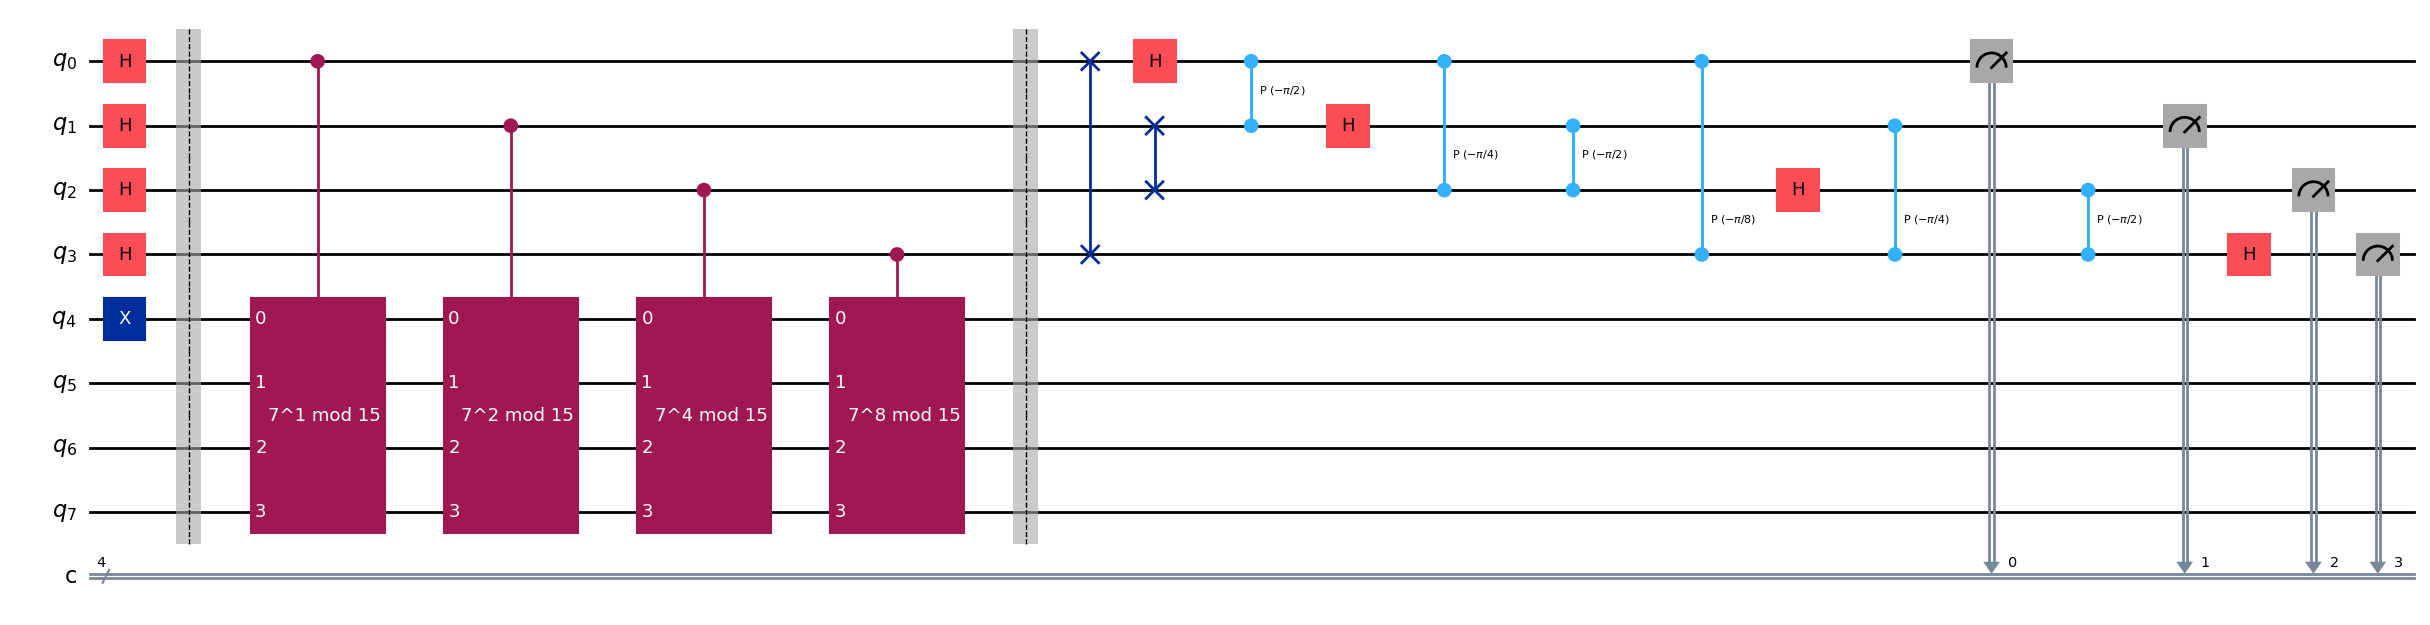

{'1000': 541, '0000': 475, '0100': 551, '1100': 481}


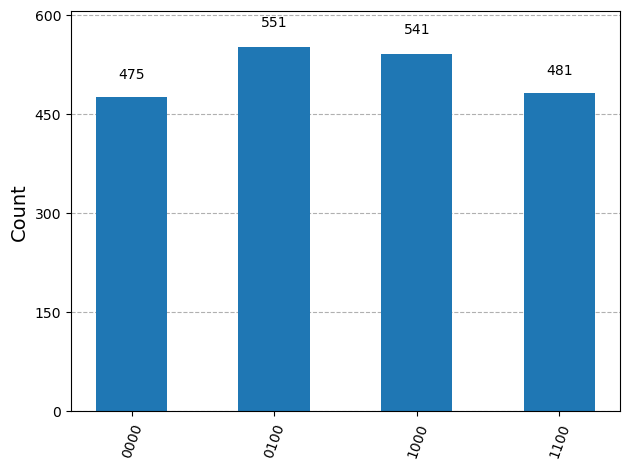

In [4]:
NCOUNT = 4
a = 7

qc = QuantumCircuit(NCOUNT + 4, NCOUNT)

for q in range(NCOUNT):
    qc.h(q)

qc.x(NCOUNT)                 # work register starts at 1
qc.barrier()

for q in range(NCOUNT):
    qc.append(c_amod15(a, 2**q), [q] + list(range(NCOUNT, NCOUNT + 4)))

qc.barrier()
qc.compose(iqft(NCOUNT), qubits=range(NCOUNT), inplace=True)
qc.measure(range(NCOUNT), range(NCOUNT))

display(qc.draw(output="mpl", fold=-1))

counts = sim.run(transpile(qc, sim), shots=2048).result().get_counts()
print(counts)
display(plot_histogram(counts))

## Reading the output

Four outcomes, evenly spread: `0000`, `0100`, `1000`, `1100`.

In decimal: 0, 4, 8, 12. Divide each by 16 to get a **phase**:

```
0/16 = 0.00      4/16 = 0.25      8/16 = 0.50      12/16 = 0.75
```

Those phases are `k/r`. Turn each into a fraction and read off the denominator.

In [5]:
N = 15
a = 7

for bits in sorted(counts):
    dec = int(bits, 2)
    phase = dec / 2**NCOUNT
    r = Fraction(phase).limit_denominator(N).denominator

    print(f"{bits}  ->  {dec:2d}/16 = {phase:.2f}  ->  r = {r}", end="")

    if r % 2 == 0:
        f1 = math.gcd(a**(r//2) - 1, N)
        f2 = math.gcd(a**(r//2) + 1, N)
        print(f"   ->  factors {f1} and {f2}")
    else:
        print("   ->  odd r, useless, run again")

0000  ->   0/16 = 0.00  ->  r = 1   ->  odd r, useless, run again
0100  ->   4/16 = 0.25  ->  r = 4   ->  factors 3 and 5
1000  ->   8/16 = 0.50  ->  r = 2   ->  factors 3 and 1
1100  ->  12/16 = 0.75  ->  r = 4   ->  factors 3 and 5


## What happened

| result | phase | r | outcome |
|---|---|---|---|
| `0000` | 0.00 | 1 | useless |
| `0100` | 0.25 | 4 | **3 and 5** |
| `1000` | 0.50 | 2 | 3 and 1, partial |
| `1100` | 0.75 | 4 | **3 and 5** |

**Half the runs give the answer. The rest you throw away and run again.**

That is normal for Shor. It is a probabilistic algorithm - cheap to retry,
and you can instantly check the answer by multiplying.

The quantum part only ever produced `r = 4`. Everything after that was `gcd`,
which your laptop does instantly.

## Honest notes

**This does not scale as written.** The `c_amod15` gate is hardcoded for 15.
Building modular exponentiation for a real RSA number needs thousands of
error-corrected qubits. Nobody has that.

**15 is not really being factored here.** The answer is baked into the gate we
wrote. This demonstrates the *mechanism*, not a working factorisation engine.
Say that out loud if you teach it.

**What is real:** the structure. Superposition over all exponents, one pass of
modular exponentiation, inverse QFT to extract the period. That part is
genuine, and it is the reason RSA has a deadline.